In [1]:
# Install extra libraries not in base Colab
!pip install -q logomaker
print('Dependencies ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 100.2 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import os, time, warnings
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import logomaker
from scipy.stats import pearsonr
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Optional: mixed precision for speed on GPU ───────────────
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed-precision (float16) enabled')
except:
    pass

print(f'TensorFlow {tf.__version__} | GPUs: {tf.config.list_physical_devices("GPU")}')

Mixed-precision (float16) enabled
TensorFlow 2.19.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────
H5_PATH      = '/content/drive/MyDrive/DLPRB_project/rnacompete2009.h5'
SAVE_DIR     = '/content/drive/MyDrive/dlprb/saved_models/'
RESULTS_DIR  = '/content/drive/MyDrive/dlprb/results/'
os.makedirs(SAVE_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Dataset explorer ─────────────────────────────────────────
def explore_h5(path):
    prots = []
    with h5py.File(path, 'r') as f:
        print(f"{'Path':<32} | {'Type':<8} | Shape")
        print('-' * 64)
        def _vis(name, obj):
            if isinstance(obj, h5py.Group) and '/' not in name:
                prots.append(name)
            tag = 'Dataset' if isinstance(obj, h5py.Dataset) else 'Group  '
            info = str(obj.shape) if isinstance(obj, h5py.Dataset) else '---'
            print(f"  {name:<30} | {tag} | {info}")
        f.visititems(_vis)
    print(f'\n🧬 {len(prots)} proteins: {prots}')
    return prots

PROTEINS = explore_h5(H5_PATH)
print(f'\nData shape convention: (N_sequences, 9_features, L_length) -> transposed to (N, L, 9)')

Mounted at /content/drive
Path                             | Type     | Shape
----------------------------------------------------------------
  Fusip                          | Group   | ---
  Fusip/X_test                   | Dataset | (50855, 9, 39)
  Fusip/X_train                  | Dataset | (45930, 9, 39)
  Fusip/X_valid                  | Dataset | (5103, 9, 39)
  Fusip/Y_test                   | Dataset | (50855, 1)
  Fusip/Y_train                  | Dataset | (45930, 1)
  Fusip/Y_valid                  | Dataset | (5103, 1)
  HuR                            | Group   | ---
  HuR/X_test                     | Dataset | (59362, 9, 39)
  HuR/X_train                    | Dataset | (53672, 9, 39)
  HuR/X_valid                    | Dataset | (5963, 9, 39)
  HuR/Y_test                     | Dataset | (59362, 1)
  HuR/Y_train                    | Dataset | (53672, 1)
  HuR/Y_valid                    | Dataset | (5963, 1)
  PTB                            | Group   | ---
  PTB/X_test      

In [4]:
# ── Data representation (Section 2.4 of paper) ───────────────
# Input: RNA sequence (4-dim one-hot) + structure (5-dim prob vector)
# = 9-dimensional vector per nucleotide position
# HDF5 stores as (N, 9, L); we transpose to (N, L, 9) for Conv1D

SEQ_DIM    = 4   # A, G, C, U one-hot
STRUCT_DIM = 5   # hairpin, inner-loop, multi-loop, external, paired
TOTAL_DIM  = SEQ_DIM + STRUCT_DIM   # 9

def load_split(h5_path, protein, split, seq_only=False):
    """Load one split from HDF5.  Returns (X, Y) with X shape (N, L, features).

    Args:
        seq_only: If True, return only the 4 sequence channels (ablation study)
    """
    with h5py.File(h5_path, 'r') as f:
        x = f[f'{protein}/X_{split}'][:]
        y = f[f'{protein}/Y_{split}'][:]
    # (N, 9, L) -> (N, L, 9)
    x_t = np.transpose(x, (0, 2, 1)).astype(np.float32)
    if seq_only:
        x_t = x_t[:, :, :SEQ_DIM]   # keep only one-hot channels
    return x_t, y.astype(np.float32)

def clamp_intensities(y, pct=0.5):
    """Clamp outlier binding intensities (Section 2.2 of paper)"""
    upper = np.percentile(y, 100 - pct)
    return np.clip(y, None, upper)

# Quick sanity check
p0 = PROTEINS[0]
xtr, ytr = load_split(H5_PATH, p0, 'train')
print(f'Protein {p0}: X_train {xtr.shape}  Y_train {ytr.shape}')
print(f'  Sequence channels: 0-3  |  Structure channels: 4-8')
print(f'  Y range: [{ytr.min():.3f}, {ytr.max():.3f}]')

Protein Fusip: X_train (45930, 39, 9)  Y_train (45930, 1)
  Sequence channels: 0-3  |  Structure channels: 4-8
  Y range: [-3.670, 4.950]


In [5]:
# ── Custom Pearson correlation metric ─────────────────────────
def pearson_metric(y_true, y_pred):
    """Pearson r as a Keras metric (float32 safe)"""
    yt = tf.cast(y_true, tf.float32)
    yp = tf.cast(y_pred, tf.float32)
    num = tf.reduce_sum((yt - tf.reduce_mean(yt)) * (yp - tf.reduce_mean(yp)))
    den = (tf.sqrt(tf.reduce_sum(tf.square(yt - tf.reduce_mean(yt))) *
                   tf.reduce_sum(tf.square(yp - tf.reduce_mean(yp)))) + K.epsilon())
    return num / den

# Keep the old name so saved .keras files load cleanly
calc_pcorr = pearson_metric


# ── CNN (vitro architecture) ─
def build_cnn(
    n_features   = TOTAL_DIM,   # 9 (seq + struct) or 4 (seq only)
    filter_sizes = [5, 11],     # 128 filters of len-5 + 128 of len-11
    filters_per  = 128,         # 128 per size => 256 total
    dense_units  = 128,         # hidden layer size
    dropout      = 0.3,
    lr           = 1e-4,        # Learning rate: 0.0001
    l2_reg       = 1e-4,):

    """ Architecture: Conv(multi-size) -> GlobalMaxPool -> Concat -> Dense(128) -> Dense(1) """
    reg = tf.keras.regularizers.l2(l2_reg)
    inp = layers.Input(shape=(None, n_features), name='rna_input')

    pool_outputs = []
    for fsize in filter_sizes:
        c = layers.Conv1D(
            filters=filters_per, kernel_size=fsize,
            activation='relu', padding='valid',
            kernel_regularizer=reg, name=f'conv_{fsize}'
        )(inp)
        p = layers.GlobalMaxPooling1D(name=f'maxpool_{fsize}')(c)
        pool_outputs.append(p)

    merged = layers.Concatenate(name='merge')(pool_outputs) if len(pool_outputs) > 1 else pool_outputs[0]
    d1  = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense1')(merged)
    d1  = layers.Dropout(dropout)(d1)
    out = layers.Dense(1, dtype='float32', name='output')(d1)

    model = Model(inp, out, name='DLPRB_CNN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=[pearson_metric]
    )
    return model

# Print architecture
demo = build_cnn()
demo.summary()
print(f'\nTotal trainable params: {demo.count_params():,}')

Model: "DLPRB_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rna_input           │ (None, None, 9)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, None, 128) │      5,888 │ rna_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_11 (Conv1D)    │ (None, None, 128) │     12,800 │ rna_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_5           │ (None, 128)       │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_11          │ (None, 128)       │          0 │ conv_11[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 256)       │          0 │ maxpool_5[0][0],  │
│                     │                   │            │ maxpool_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │     32,896 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable params: 51,713


In [6]:
# ───────────── Bidirectional RNN/GRU  ─────────────
def build_rnn(
    n_features  = TOTAL_DIM,
    gru_units   = 64,       # cell size 64
    dense_units = 128,
    dropout     = 0.3,
    lr          = 1e-4,
    l2_reg      = 1e-4,
):
    """
    Architecture: BiGRU -> Dense(128) -> Dense(1)
    GRU chosen over LSTM per paper recommendation (lower params, same performance).
    """
    reg = tf.keras.regularizers.l2(l2_reg)
    inp = layers.Input(shape=(None, n_features), name='rna_input')

    # Bidirectional GRU – processes sequence forward AND backward
    rnn = layers.Bidirectional(
        layers.GRU(gru_units, return_sequences=False),
        name='bigru'
    )(inp)

    d1  = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense1')(rnn)
    d1  = layers.Dropout(dropout)(d1)
    out = layers.Dense(1, dtype='float32', name='output')(d1)

    model = Model(inp, out, name='DLPRB_RNN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=[pearson_metric]
    )
    return model

# Print architecture
demo_rnn = build_rnn()
demo_rnn.summary()
print(f'\nTotal trainable params: {demo_rnn.count_params():,}')

Model: "DLPRB_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rna_input (InputLayer)          │ (None, None, 9)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ (None, 128)            │        28,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,441 (177.50 KB)

 Trainable params: 45,441 (177.50 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable params: 45,441


In [7]:
# ────── Hyper-parameters ──────
EPOCHS   = 60
BATCH    = 128   # Batch Size
PATIENCE = 8     # early stopping patience

# ── Training helper ───────────────────────────────────────────
def train_protein(protein, arch='cnn', seq_only=False, verbose=0):
    """
    Full training pipeline for one protein.
    Returns: dict with pearson_r on test set, training history, model path.
    """
    n_feats = SEQ_DIM if seq_only else TOTAL_DIM
    suffix  = ('seq_only' if seq_only else 'seq_struct') + f'_{arch}'

    # Load data
    xtr, ytr = load_split(H5_PATH, protein, 'train', seq_only=seq_only)
    xvl, yvl = load_split(H5_PATH, protein, 'valid', seq_only=seq_only)
    xte, yte = load_split(H5_PATH, protein, 'test',  seq_only=seq_only)

    # Clamp outliers
    ytr = clamp_intensities(ytr)

    # Build model
    if arch == 'cnn':
        model = build_cnn(n_features=n_feats)
    else:
        model = build_rnn(n_features=n_feats)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_pearson_metric', mode='max',
                      patience=PATIENCE, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_pearson_metric', mode='max',
                          factor=0.5, patience=4, verbose=0),
    ]

    t0 = time.time()
    hist = model.fit(
        xtr, ytr,
        validation_data=(xvl, yvl),
        epochs=EPOCHS, batch_size=BATCH,
        callbacks=callbacks, verbose=verbose
    )

    # Evaluate
    y_pred = model.predict(xte, batch_size=256, verbose=0).flatten()
    r, pval = pearsonr(yte.flatten(), y_pred)
    elapsed = time.time() - t0

    # Save
    m_path = os.path.join(SAVE_DIR, f'{protein}_{suffix}_model.keras')
    model.save(m_path)

    return {
        'protein': protein, 'arch': arch, 'seq_only': seq_only,
        'pearson_r': float(r), 'p_value': float(pval),
        'epochs_run': len(hist.history['loss']),
        'time_s': round(elapsed, 1),
        'model_path': m_path,
        'history': hist.history
    }


# ── Run all proteins : CNN (seq+struct) ───────────────────────
print('=' * 60)
print('PHASE 1: CNN  |  Sequence + Structure ')
print('=' * 60)

results_cnn = {}
for prot in PROTEINS:
    res = train_protein(prot, arch='cnn', seq_only=False, verbose=0)
    results_cnn[prot] = res
    print(f'  {prot:<8}  r={res["pearson_r"]:+.4f}   epochs={res["epochs_run"]:>3}   {res["time_s"]}s')

avg_cnn = np.mean([v['pearson_r'] for v in results_cnn.values()])
print(f'\n  ➤ Average Pearson r (CNN, seq+struct): {avg_cnn:.4f}')


# ── Run all proteins : RNN (seq+struct) ───────────────────────
print('\n' + '=' * 60)
print('PHASE 2: RNN  |  Sequence + Structure  (paper BiGRU arch)')
print('=' * 60)

results_rnn = {}
for prot in PROTEINS:
    res = train_protein(prot, arch='rnn', seq_only=False, verbose=0)
    results_rnn[prot] = res
    print(f'  {prot:<8}  r={res["pearson_r"]:+.4f}   epochs={res["epochs_run"]:>3}   {res["time_s"]}s')

avg_rnn = np.mean([v['pearson_r'] for v in results_rnn.values()])
print(f'\n  ➤ Average Pearson r (RNN, seq+struct): {avg_rnn:.4f}')


# ── Ablation – CNN sequence only (no structure) ───────────────
print('\n' + '=' * 60)
print('PHASE 3: CNN  |  Sequence ONLY  (ablation, Section 3.1)')
print('=' * 60)

results_cnn_seq = {}
for prot in PROTEINS:
    res = train_protein(prot, arch='cnn', seq_only=True, verbose=0)
    results_cnn_seq[prot] = res
    print(f'  {prot:<8}  r={res["pearson_r"]:+.4f}   epochs={res["epochs_run"]:>3}   {res["time_s"]}s')

avg_cnn_seq = np.mean([v['pearson_r'] for v in results_cnn_seq.values()])
print(f'\n  ➤ Average Pearson r (CNN, seq only): {avg_cnn_seq:.4f}')
print(f'  ➤ Structure contribution: Δr = {avg_cnn - avg_cnn_seq:+.4f}')

PHASE 1: CNN  |  Sequence + Structure  (paper primary arch)
  Fusip     r=+0.7089   epochs= 58   86.0s
  HuR       r=+0.8301   epochs= 54   83.9s
  PTB       r=+0.5780   epochs= 54   91.2s
  RBM4      r=+0.8089   epochs= 60   87.2s
  SF2       r=+0.7382   epochs= 48   85.2s
  SLM2      r=+0.7131   epochs= 40   71.2s
  U1A       r=+0.6910   epochs= 53   36.8s
  VTS1      r=+0.6361   epochs= 60   84.1s
  YB1       r=+0.4379   epochs= 40   94.0s

  ➤ Average Pearson r (CNN, seq+struct): 0.6825

PHASE 2: RNN  |  Sequence + Structure  (paper BiGRU arch)
  Fusip     r=+0.7210   epochs= 60   270.4s
  HuR       r=+0.8458   epochs= 60   281.0s
  PTB       r=+0.5943   epochs= 60   309.1s
  RBM4      r=+0.8325   epochs= 60   274.0s
  SF2       r=+0.7402   epochs= 60   314.1s
  SLM2      r=+0.7415   epochs= 60   282.0s
  U1A       r=+0.6939   epochs= 60   83.3s
  VTS1      r=+0.5487   epochs= 60   193.8s
  YB1       r=+0.4301   epochs= 60   375.7s

  ➤ Average Pearson r (RNN, seq+struct): 0.6831



In [15]:
# ── Per-protein results table ─────────────────────────────────
rows = []
for prot in PROTEINS:
    rows.append({
        'Protein'              : prot,
        'CNN (seq+struct)'     : round(results_cnn[prot]['pearson_r'],    4),
        'RNN (seq+struct)'     : round(results_rnn[prot]['pearson_r'],    4),
        'CNN (seq only)'       : round(results_cnn_seq[prot]['pearson_r'], 4),
        'Struct gain (CNN)'    : round(results_cnn[prot]['pearson_r'] -
                                       results_cnn_seq[prot]['pearson_r'], 4),
    })

df_res = pd.DataFrame(rows).set_index('Protein')

# Add means row
df_res.loc['── MEAN ──'] = df_res.mean()

print('\n===  Per-Protein Results  ===')
print(df_res.to_string())
# Save to CSV
df_res.to_csv(os.path.join(RESULTS_DIR, 'per_protein_results.csv'))
print('\n Results saved to', RESULTS_DIR)


===  Per-Protein Results  ===
            CNN (seq+struct)  RNN (seq+struct)  CNN (seq only)  Struct gain (CNN)
Protein                                                                          
Fusip               0.708900          0.721000        0.699700           0.009300
HuR                 0.830100          0.845800        0.819200           0.010900
PTB                 0.578000          0.594300        0.570800           0.007200
RBM4                0.808900          0.832500        0.794300           0.014500
SF2                 0.738200          0.740200        0.741800          -0.003500
SLM2                0.713100          0.741500        0.699800           0.013300
U1A                 0.691000          0.693900        0.680500           0.010500
VTS1                0.636100          0.548700        0.600400           0.035700
YB1                 0.437900          0.430100        0.436400           0.001500
── MEAN ──          0.682467          0.683111        0.671433     

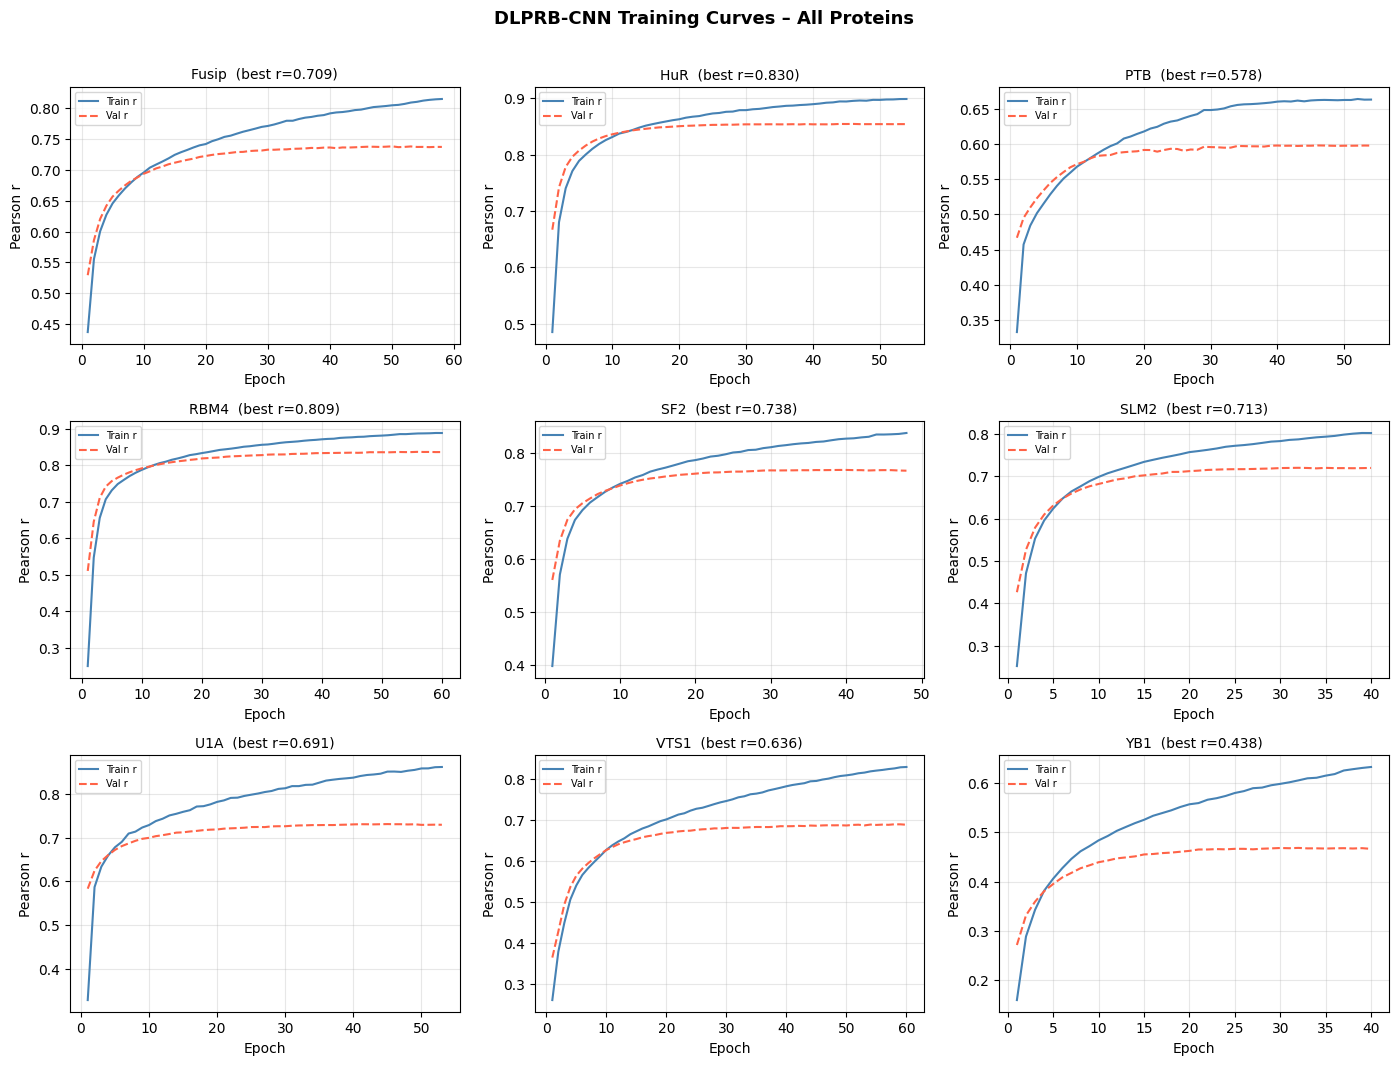

✅ Saved training curves


In [9]:
# ── Plot training curves for all proteins (CNN) ───────────────
n_prots = len(PROTEINS)
ncols   = 3
nrows   = (n_prots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, prot in enumerate(PROTEINS):
    ax  = axes[i]
    h   = results_cnn[prot]['history']
    ep  = range(1, len(h['pearson_metric']) + 1)

    ax.plot(ep, h['pearson_metric'],     label='Train r', color='steelblue')
    ax.plot(ep, h['val_pearson_metric'], label='Val r',   color='tomato',   linestyle='--')
    ax.set_title(f'{prot}  (best r={results_cnn[prot]["pearson_r"]:.3f})', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Pearson r')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('DLPRB-CNN Training Curves', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_cnn.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved training curves')

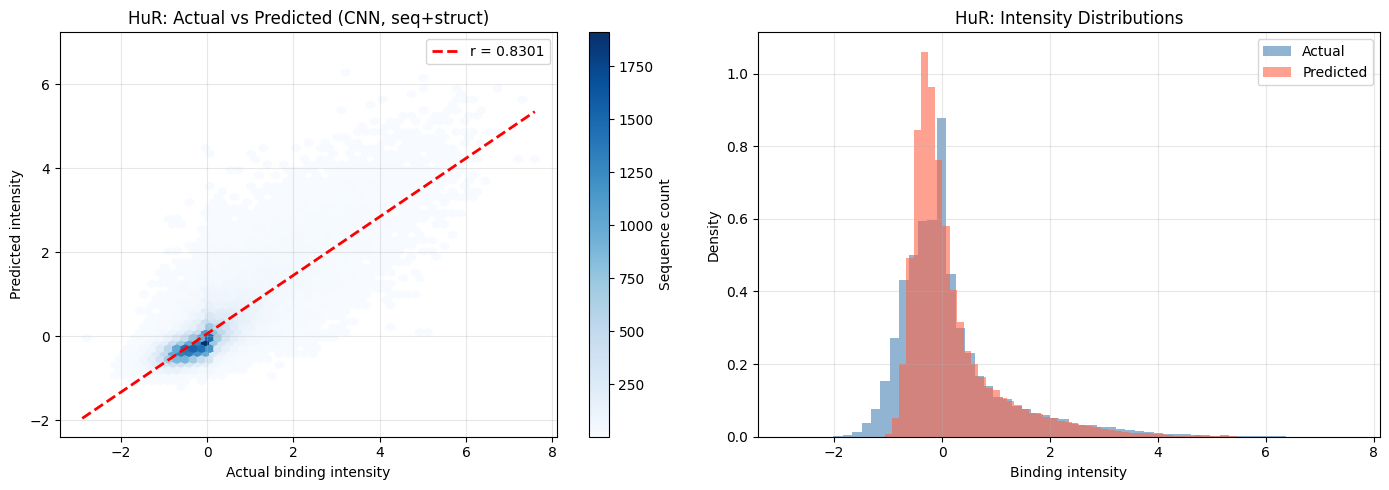

In [10]:
# ── Scatter / density plot for chosen protein ─────────────────
TARGET_PROT = 'HuR'   # change to any protein in PROTEINS

m_path = results_cnn[TARGET_PROT]['model_path']
model  = tf.keras.models.load_model(m_path, custom_objects={'pearson_metric': pearson_metric})

xte, yte = load_split(H5_PATH, TARGET_PROT, 'test')
y_pred   = model.predict(xte, batch_size=256, verbose=0).flatten()
y_true   = yte.flatten()
r, _     = pearsonr(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: hex-density scatter
ax = axes[0]
hb = ax.hexbin(y_true, y_pred, gridsize=55, cmap='Blues', mincnt=1)
plt.colorbar(hb, ax=ax, label='Sequence count')
m, b = np.polyfit(y_true, y_pred, 1)
xl = np.linspace(y_true.min(), y_true.max(), 100)
ax.plot(xl, m * xl + b, 'r--', lw=2, label=f'r = {r:.4f}')
ax.set_xlabel('Actual binding intensity'); ax.set_ylabel('Predicted intensity')
ax.set_title(f'{TARGET_PROT}: Actual vs Predicted (CNN, seq+struct)')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: distribution comparison
ax2 = axes[1]
ax2.hist(y_true, bins=60, alpha=0.6, color='steelblue', label='Actual',    density=True)
ax2.hist(y_pred, bins=60, alpha=0.6, color='tomato',    label='Predicted', density=True)
ax2.set_xlabel('Binding intensity'); ax2.set_ylabel('Density')
ax2.set_title(f'{TARGET_PROT}: Intensity Distributions')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'scatter_{TARGET_PROT}.png'), dpi=150, bbox_inches='tight')
plt.show()

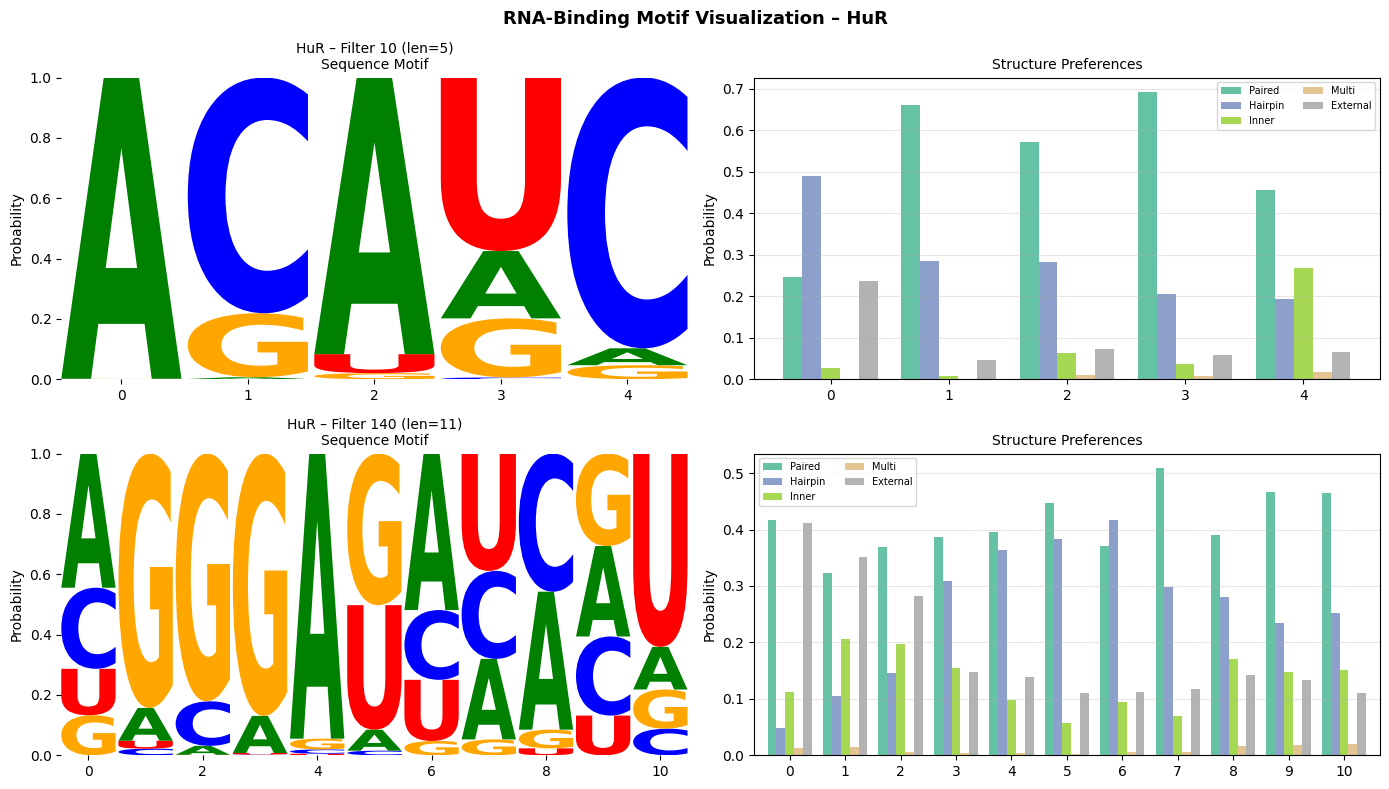

✅ Saved motif plot for HuR


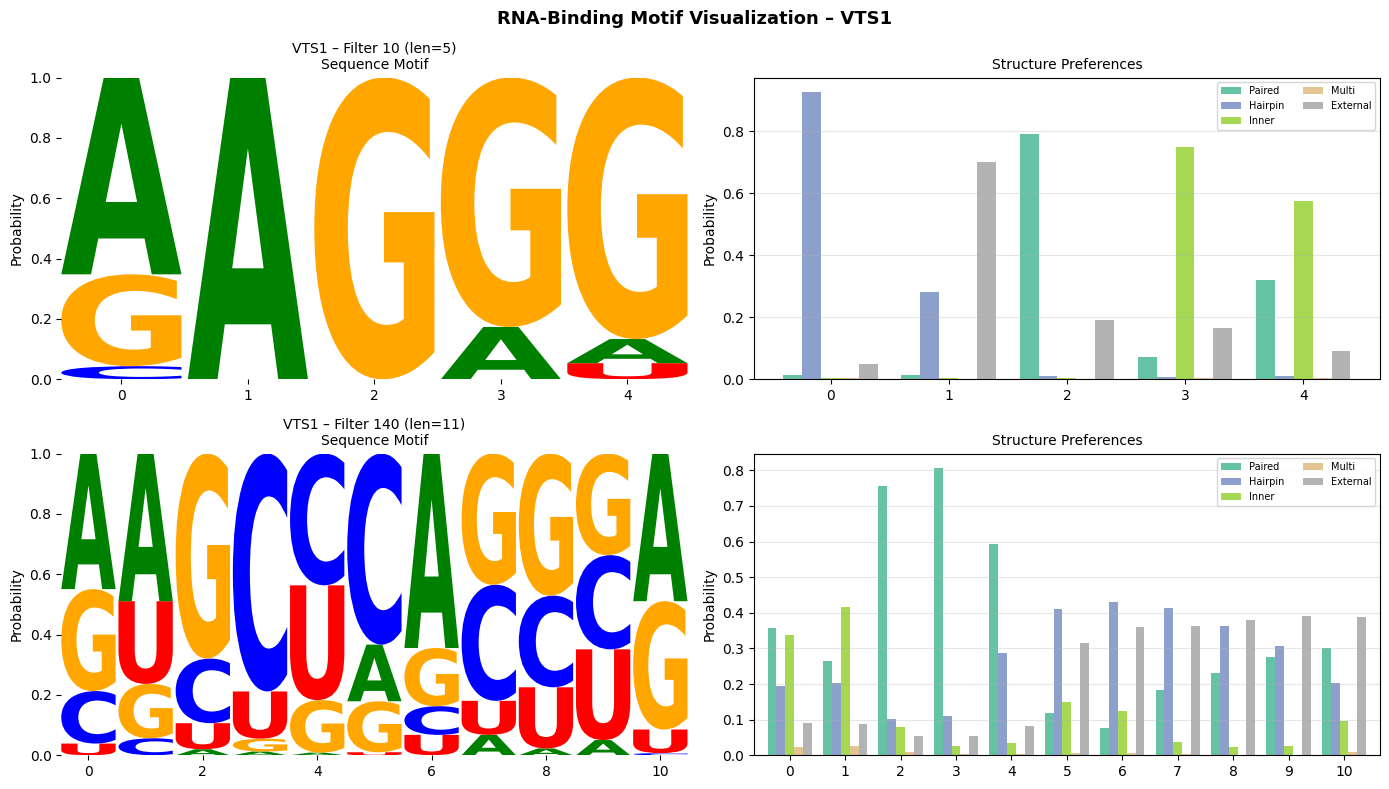

✅ Saved motif plot for VTS1


In [12]:
# ── Filter-level motif extraction ────────
def extract_pwm(model, x_test, global_filter_idx, activation_pct=98):
    """
    Extract Position Weight Matrix from a CNN filter.
    Finds top-activating test sequences for a given filter and
    builds a normalized frequency matrix (paper Section 2.8).

    Returns: (pwm_norm [L, 4], pwm_struct [L, 5], filter_size)
    """
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)]

    # Map global index -> specific conv layer + local index
    current_layer, local_idx = None, 0
    seen = 0
    for lyr in conv_layers:
        if global_filter_idx < seen + lyr.filters:
            current_layer = lyr
            local_idx     = global_filter_idx - seen
            break
        seen += lyr.filters

    if current_layer is None:
        return None, None, 0

    filt_sz  = current_layer.kernel_size[0]
    extractor = Model(inputs=model.inputs, outputs=current_layer.output)
    acts      = extractor.predict(x_test, batch_size=256, verbose=0)
    filt_acts = acts[:, :, local_idx]               # (N, L-filt_sz+1)
    max_per_seq = filt_acts.max(axis=1)             # (N,)
    threshold   = np.percentile(max_per_seq, activation_pct)

    seq_slices    = []
    struct_slices = []
    for i in range(len(x_test)):
        if max_per_seq[i] > threshold:
            pos = filt_acts[i].argmax()
            if pos + filt_sz <= x_test.shape[1]:
                seq_slices.append(   x_test[i, pos:pos+filt_sz, :SEQ_DIM]   )
                struct_slices.append(x_test[i, pos:pos+filt_sz, SEQ_DIM:]   )

    if not seq_slices:
        return None, None, filt_sz

    def norm(arr):
        s = np.sum(arr, axis=0)           # (filt_sz, dim)
        d = s.sum(axis=1, keepdims=True)
        d[d == 0] = 1
        return s / d

    return norm(seq_slices), norm(struct_slices), filt_sz


def plot_sequence_logo(pwm, struct_pwm, protein, filter_idx, filt_sz, ax_seq, ax_str):
    """Draw sequence + structure logos side-by-side on given axes."""
    COLS_SEQ    = ['A', 'C', 'G', 'U']
    COLS_STRUCT = ['Paired', 'Hairpin', 'Inner', 'Multi', 'External']

    if pwm is not None:
        df_seq = pd.DataFrame(pwm, columns=COLS_SEQ)
        logo   = logomaker.Logo(df_seq, ax=ax_seq, color_scheme='classic')
        logo.style_spines(visible=False)
        ax_seq.set_title(f'{protein} – Filter {filter_idx} (len={filt_sz})\nSequence Motif',
                         fontsize=10)
        ax_seq.set_ylabel('Probability')
    else:
        ax_seq.text(0.5, 0.5, 'No motif found', ha='center', va='center')
        ax_seq.axis('off')

    if struct_pwm is not None:
        df_str = pd.DataFrame(struct_pwm, columns=COLS_STRUCT)
        df_str.plot(kind='bar', ax=ax_str, colormap='Set2', width=0.8)
        ax_str.set_title('Structure Preferences', fontsize=10)
        ax_str.set_ylabel('Probability')
        ax_str.set_xticklabels(range(filt_sz), rotation=0)
        ax_str.legend(fontsize=7, ncol=2)
        ax_str.grid(axis='y', alpha=0.3)
    else:
        ax_str.axis('off')


# ── Visualise top filters for HuR and VTS1 (paper Fig 6) ─────
VIZ_PROTEINS = ['HuR', 'VTS1']   # subset; adjust as needed
FILTER_IDXS  = [10, 140]         # one short-filter (0-127) + one long (128-255)

for prot in VIZ_PROTEINS:
    if prot not in results_cnn:
        print(f'{prot} not in results, skipping')
        continue

    m_path = results_cnn[prot]['model_path']
    mdl    = tf.keras.models.load_model(m_path, custom_objects={'pearson_metric': pearson_metric})
    xte, _ = load_split(H5_PATH, prot, 'test')

    fig, axes = plt.subplots(len(FILTER_IDXS), 2, figsize=(14, 4 * len(FILTER_IDXS)))
    if len(FILTER_IDXS) == 1:
        axes = [axes]

    for row, fidx in enumerate(FILTER_IDXS):
        pwm, s_pwm, fsz = extract_pwm(mdl, xte, fidx)
        plot_sequence_logo(pwm, s_pwm, prot, fidx, fsz,
                           axes[row][0], axes[row][1])

    fig.suptitle(f'RNA-Binding Motif Visualization – {prot}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'motif_{prot}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved motif plot for {prot}')

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Interactive Motif Visualization Dashboard ─────────────────
rbp_dd      = widgets.Dropdown(options=PROTEINS, value=PROTEINS[0], description='Protein:')
arch_dd     = widgets.Dropdown(options=['cnn'], value='cnn', description='Arch:')
filt_slider = widgets.IntSlider(value=10, min=0, max=255, step=1,
                                description='Filter:', style={'description_width': '60px'})
pct_slider  = widgets.IntSlider(value=98, min=90, max=99, step=1,
                                description='Top %:', style={'description_width': '60px'})
btn         = widgets.Button(description='Visualize Motif', button_style='primary')
out_area    = widgets.Output()

def on_click(b):
    prot   = rbp_dd.value
    f_idx  = filt_slider.value
    pct    = pct_slider.value
    res_d  = results_cnn

    with out_area:
        clear_output(wait=True)
        print(f'Loading {prot} model…')
        if prot not in res_d:
            print('No model found for this protein/arch combination.'); return

        try:
            mdl = tf.keras.models.load_model(
                res_d[prot]['model_path'],
                custom_objects={'pearson_metric': pearson_metric}
            )
            xte, _ = load_split(H5_PATH, prot, 'test')
        except Exception as e:
            print(f'Error: {e}'); return

        pwm, s_pwm, fsz = extract_pwm(mdl, xte, f_idx, activation_pct=pct)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        plot_sequence_logo(pwm, s_pwm, prot, f_idx, fsz, axes[0], axes[1])
        plt.tight_layout()
        plt.show()

btn.on_click(on_click)

ui = widgets.VBox([
    widgets.HTML('<h3>🔬 DLPRB Motif Visualization Dashboard</h3>'),
    widgets.HTML('<i>Filters 0–127: length-5 | Filters 128–255: length-11</i>'),
    widgets.HBox([rbp_dd, arch_dd, filt_slider, pct_slider]),
    btn,
    out_area
])
display(ui)

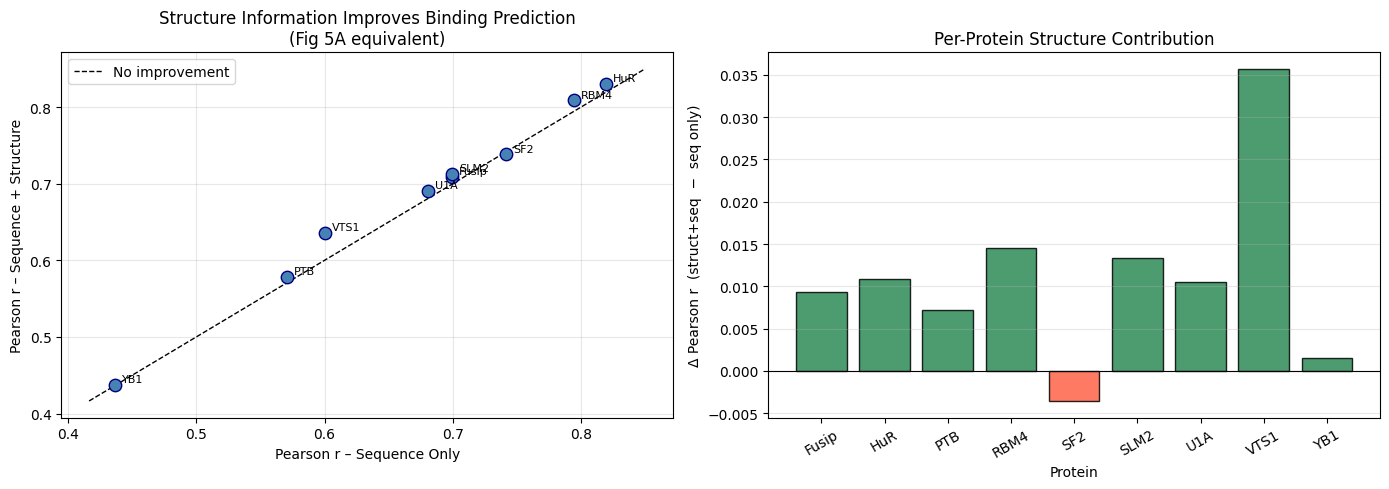

Wilcoxon test (struct+seq > seq only): stat=43.00  p=5.8594e-03
Mean Δr = +0.0110   (paper reports ~0.014 improvement)


In [14]:
# ── Section 3.4 replication – weight of RNA structure ─────────
# Compare CNN seq+struct vs CNN seq-only per protein (Fig 5A equivalent)

prots_list = list(PROTEINS)
r_ss  = [results_cnn[p]['pearson_r']     for p in prots_list]
r_seq = [results_cnn_seq[p]['pearson_r'] for p in prots_list]
delta = [a - b for a, b in zip(r_ss, r_seq)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter – seq+struct vs seq-only
ax = axes[0]
ax.scatter(r_seq, r_ss, s=80, color='steelblue', edgecolors='navy', zorder=3)
lims = [min(r_seq + r_ss) - 0.02, max(r_seq + r_ss) + 0.02]
ax.plot(lims, lims, 'k--', lw=1, label='No improvement')
for p, x, y in zip(prots_list, r_seq, r_ss):
    ax.annotate(p, (x, y), textcoords='offset points', xytext=(5, 2), fontsize=8)
ax.set_xlabel('Pearson r – Sequence Only')
ax.set_ylabel('Pearson r – Sequence + Structure')
ax.set_title('Structure Information Improves Binding Prediction\n(Fig 5A equivalent)')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: bar – delta per protein
ax2 = axes[1]
colors = ['seagreen' if d >= 0 else 'tomato' for d in delta]
ax2.bar(prots_list, delta, color=colors, edgecolor='black', alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Protein')
ax2.set_ylabel('Δ Pearson r  (struct+seq  −  seq only)')
ax2.set_title('Per-Protein Structure Contribution')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'ablation_structure.png'), dpi=150, bbox_inches='tight')
plt.show()

from scipy.stats import wilcoxon
stat, pval = wilcoxon(r_ss, r_seq, alternative='greater')
print(f'Wilcoxon test (struct+seq > seq only): stat={stat:.2f}  p={pval:.4e}')
print(f'Mean Δr = {np.mean(delta):+.4f}   (paper reports ~0.014 improvement)')